In [30]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd
import random

import networkx as nx

# Utils

In [31]:
def compute_avg_deg_of_random_nodes_and_neighbors(G, Rs, seed=42):
    rng = np.random.default_rng(seed)
    Rs = np.asarray(Rs)

    nodes = np.array(list(G.nodes))
    degrees = dict(G.degree())

    random_nodes = rng.choice(nodes, size=np.max(Rs), replace=False)
    random_neighbors = np.array([
        rng.choice(list(G.neighbors(n)))
        for n in random_nodes
    ])

    node_degrees = np.array([degrees[n] for n in random_nodes])
    neighbor_degrees = np.array([degrees[n] for n in random_neighbors])

    avg_degrees = np.cumsum(node_degrees)[Rs - 1] / Rs
    avg_degrees_neighbors = np.cumsum(neighbor_degrees)[Rs - 1] / Rs

    return avg_degrees, avg_degrees_neighbors


def compute_avg_clustering_coefficient(G, Rs, seed=42):
    rng = np.random.default_rng(seed)
    Rs = np.asarray(Rs)

    nodes = np.array(list(G.nodes))
    clustering_coeffs = nx.clustering(G)

    random_nodes = rng.choice(nodes, size=np.max(Rs), replace=False)
    node_clustering_coeffs = np.array([clustering_coeffs[n] for n in random_nodes])

    avg_clustering_coeffs = np.cumsum(node_clustering_coeffs)[Rs - 1] / Rs

    return avg_clustering_coeffs

# Quiz 1

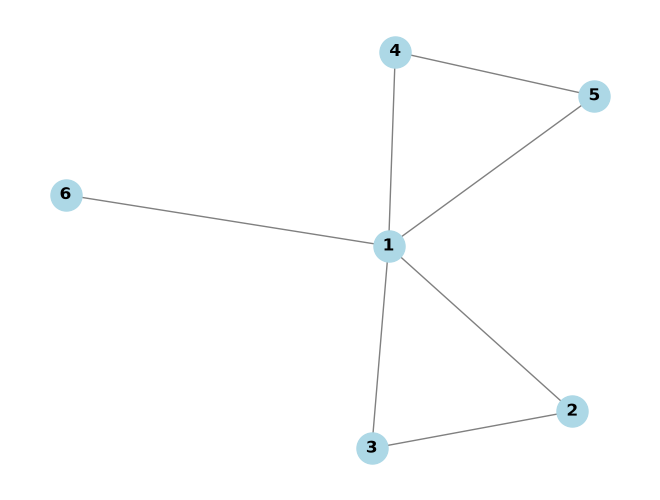

Number of links: 7
Diameter: 2
Clustering coefficient of node 1: 0.2
Average clustering coefficient: 0.7000000000000001
Clustering coefficient: 0.42857142857142855


In [32]:
edge_list = [(1,2), (1,3), (1,4), (1,5), (1,6),
            (2,1), (2,3),
            (3,1), (3,2),
            (4,1), (4,5),
            (5,1), (5,4),
            (6,1)]

G_1 = nx.Graph(edge_list)

pos = nx.spring_layout(G_1, seed=42)
nx.draw(G_1, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=12, font_weight='bold', edge_color='gray')
plt.show()
print(f"Number of links: {G_1.number_of_edges()}")
print(f"Diameter: {nx.diameter(G_1)}")
print("Clustering coefficient of node 1:", nx.clustering(G_1, 1))
print("Average clustering coefficient:", nx.average_clustering(G_1))
print(f"Clustering coefficient: {nx.transitivity(G_1)}")

# Quiz 2

## Data

In [33]:
Gk=nx.read_adjlist("data/karate_edges_77.txt",nodetype=int)

listB=[1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 17, 18, 20, 22]
listA=[10, 15, 16, 19, 21, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34]
grp_A = set(listA)
grp_B = set(listB)

print(f"Number of nodes in the graph: {Gk.number_of_nodes()}")
print(f"Number of edges in the graph: {Gk.number_of_edges()}")

Number of nodes in the graph: 34
Number of edges in the graph: 77


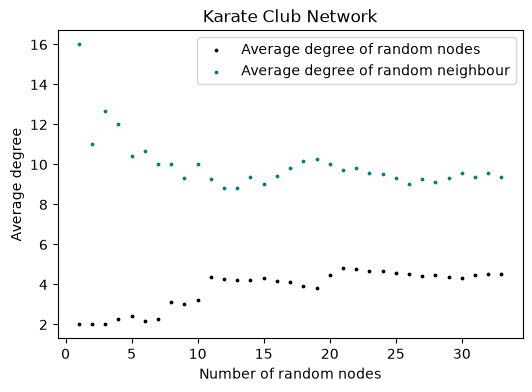

Average degree of the graph: 3.80
Average degree of random neighbour: 9.99


In [34]:
Rs = np.arange(1, 34)
avg_degree_karate, avg_degree_neighbour_karate = compute_avg_deg_of_random_nodes_and_neighbors(Gk, Rs)


plt.figure(figsize=(6, 4))
plt.scatter(Rs, avg_degree_karate,color="black", s=3, label="Average degree of random nodes")
plt.scatter(Rs, avg_degree_neighbour_karate, color="teal", s=3, label="Average degree of random neighbour")

plt.title("Karate Club Network")
plt.xlabel("Number of random nodes")
plt.ylabel("Average degree")
plt.legend()
plt.show()

print(f"Average degree of the graph: {np.mean(avg_degree_karate):.2f}")
print(f"Average degree of random neighbour: {np.mean(avg_degree_neighbour_karate):.2f}")

## Exercise 4.1

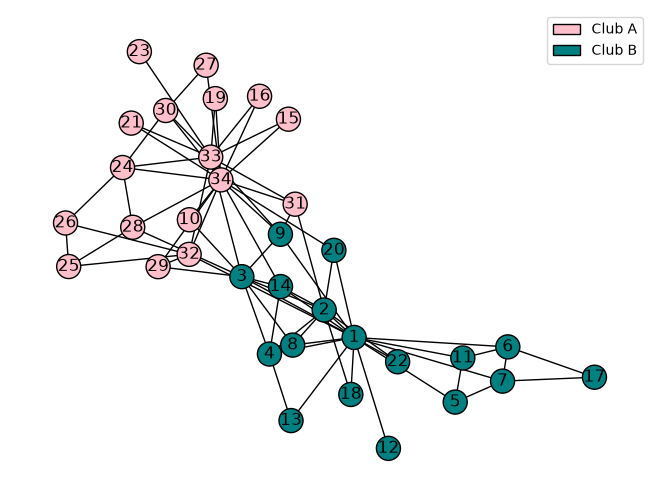

In [35]:
node_colours = []
for node in Gk.nodes():
    if node in grp_A:
        node_colours.append('pink')
    elif node in grp_B:
        node_colours.append('teal')


nx.draw(Gk, pos=nx.spring_layout(Gk, seed=42), node_color=node_colours, with_labels=True, edgecolors="black")

plt.legend(handles=[Patch(facecolor="pink", edgecolor="black", label="Club A"), Patch(facecolor="teal", edgecolor="black", label="Club B") ])
plt.show()

## Exercise 4.2

In [36]:
fb_df = pd.read_csv("data/facebook.txt", sep=" ", header=None, names=["source", "target"])

In [37]:
G = nx.from_pandas_edgelist(fb_df, source='source', target='target', create_using=nx.Graph())

print("Is the graph simple?", not any(nx.selfloop_edges(G)))
print("Number of nodes in the graph:", G.number_of_nodes())
print("Number of edges in the graph:", G.number_of_edges())

max_degree_node, degree = max(G.degree, key=lambda item: item[1])
print(f"Node with the highest degree: {max_degree_node}, Degree: {degree}")

Is the graph simple? True
Number of nodes in the graph: 4039
Number of edges in the graph: 88234
Node with the highest degree: 107, Degree: 1045


In [38]:
H = G.copy()
deg_cutoff = 0

leaves = [ v for v, d in H.degree() if d <= deg_cutoff]
H.remove_nodes_from(leaves)  # reduce nodes with degree <= deg_cutoff

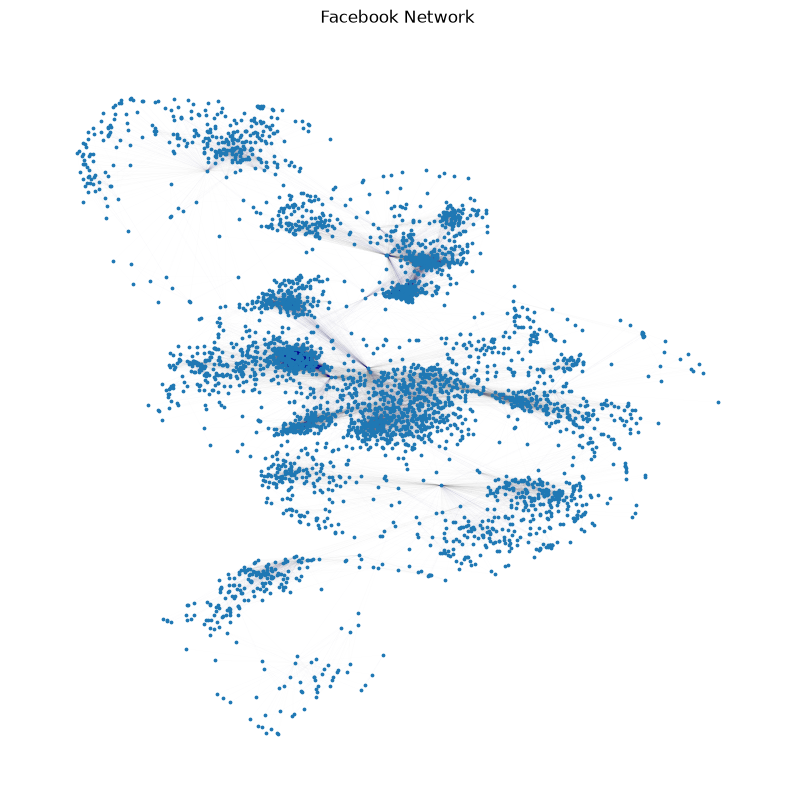

In [39]:
pos = nx.spring_layout(H, method="force", iterations=20, seed=42)

fig, ax = plt.subplots(figsize=(10, 10))

nx.draw_networkx_edges(H, pos, ax=ax, width=0.05, alpha=0.08, edge_color="darkblue", arrows=False)
nx.draw_networkx_nodes(H,pos,ax=ax,node_size=3)
plt.title(f"Facebook Network", fontsize=12)

ax.set_axis_off()
plt.show()

## Exercise 4.3

In [40]:
rand_node = np.random.RandomState(42).choice(list(G.nodes))
print(f"Randomly selected node: {rand_node}, Degree: {G.degree(rand_node)}")

Randomly selected node: 2238, Degree: 13


In [41]:
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"Average degree of the graph: {avg_degree:.2f}")  

Average degree of the graph: 43.69


In [42]:
rand_node_i = np.random.RandomState(42).choice(list(G.nodes))
rand_node_j = np.random.RandomState(42).choice(list(G.neighbors(rand_node_i)))
print(f"Randomly selected nodes: {rand_node_i} (Degree: {G.degree(rand_node_i)}), {rand_node_j} (Degree: {G.degree(rand_node_j)})")

Randomly selected nodes: 2238 (Degree: 13), 2335 (Degree: 34)


In [43]:
R = 50
random_nodes = np.random.RandomState(42).choice(list(G.nodes), size=R, replace=False)
random_neighbour = [np.random.choice(list(G.neighbors(n))) for n in random_nodes]

avg_degree_random_nodes = sum(G.degree(n) for n in random_nodes) / len(random_nodes)
avg_degree_random_neighbour = sum(G.degree(n) for n in random_neighbour) / len(random_neighbour)

print(f"Average degree of {R} random neighbour: {avg_degree_random_neighbour:.2f}")
print(f"Average degree of {R} random nodes: {avg_degree_random_nodes:.2f}")

Average degree of 50 random neighbour: 132.04
Average degree of 50 random nodes: 37.90


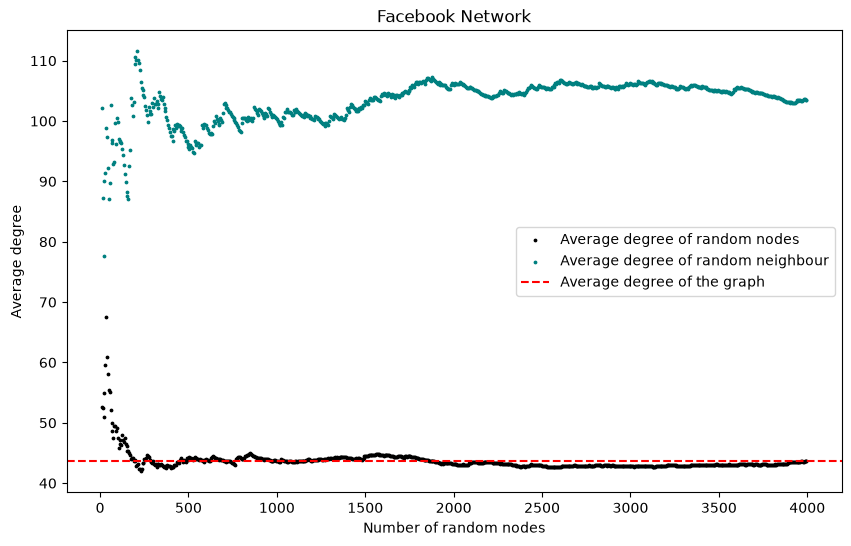

Average degree of the graph: 43.69
Average degree of random neighbour: 103.27


In [44]:
Rs = np.arange(10, 4000, 5)
avg_degrees, avg_degrees_neighbour = compute_avg_deg_of_random_nodes_and_neighbors(G, Rs)


plt.figure(figsize=(10, 6))
plt.scatter(Rs, avg_degrees,color="black", s=3, label="Average degree of random nodes")
plt.scatter(Rs, avg_degrees_neighbour, color="teal", s=3, label="Average degree of random neighbour")
plt.axhline(y=avg_degree, color="red", linestyle="--", label="Average degree of the graph")

plt.title("Facebook Network")
plt.xlabel("Number of random nodes")
plt.ylabel("Average degree")
plt.legend()
plt.show()

print(f"Average degree of the graph: {avg_degree:.2f}")
print(f"Average degree of random neighbour: {np.mean(avg_degrees_neighbour):.2f}")

Clustering coefficients

average clustering coefficient of the graph: 0.6055467186200862
largest clustering coefficient of the graph: 1.0


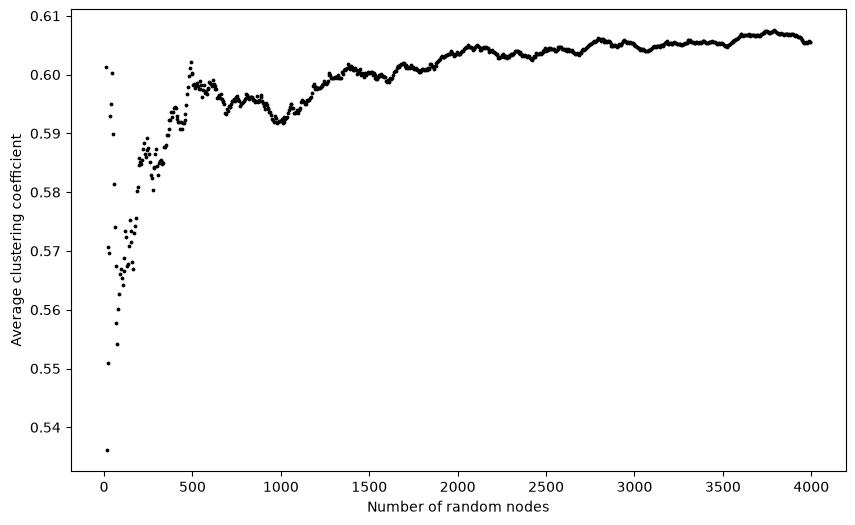

In [45]:
print("average clustering coefficient of the graph:", nx.average_clustering(G))
print("largest clustering coefficient of the graph:", max(nx.clustering(G).values()))

avg_clustering_coeffs = compute_avg_clustering_coefficient(G, Rs)

plt.figure(figsize=(10, 6))
plt.scatter(Rs, avg_clustering_coeffs, color="black", s=3)
plt.xlabel("Number of random nodes")
plt.ylabel("Average clustering coefficient")
plt.show()

#### Facebook GIF

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

degree = dict(G.degree())

cutoffs = [
    0, 1, 2, 3, 4, 5,
    7, 10, 15, 20,
    25, 30, 35, 40,
    45, 50, 60, 70,
    80, 90, 100, 200
]

pos = nx.spring_layout(G,method="force", iterations=20,seed=42)

fig, ax = plt.subplots(figsize=(10, 10))


def update(deg_cutoff):
    ax.clear()

    nodes_to_keep = [
        v for v in G.nodes()
        if degree[v] > deg_cutoff
    ]

    H = G.subgraph(nodes_to_keep)

    node_sizes = [
        6 - 3 * np.log1p(degree[v])
        for v in H.nodes()
    ]

    nx.draw_networkx_edges(
        H,
        pos,
        ax=ax,
        width=0.05,
        alpha=0.08,
        edge_color="darkblue"
    )

    nx.draw_networkx_nodes(
        H,
        pos,
        ax=ax,
        node_size=node_sizes
    )

    ax.set_title(
        rf"Facebook Network: degree $> {deg_cutoff}$"
        "\n"
        f"{H.number_of_nodes()} nodes, "
        f"{H.number_of_edges()} edges",
        fontsize=12
    )

    ax.set_axis_off()


ani = FuncAnimation(
    fig,
    update,
    frames=cutoffs,
    interval=500,
    repeat=True
)

plt.close()

ani.save(
    "outputs/facebook_degree_animation.gif",
    writer="pillow",
    fps=2
)

c:\Users\Mani\anaconda3\envs\data5441\Lib\site-packages\matplotlib\collections.py:1115: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


# US airport data 

In [47]:
air_df = pd.read_csv("data/USairport_2010_links.txt", sep=" ", header=None, names=["source", "target"])
G_air = nx.from_pandas_edgelist(air_df, source='source', target='target', create_using=nx.Graph())

avg_degree_air = sum(dict(G_air.degree()).values()) / G_air.number_of_nodes()

print("Number of nodes in the graph:", G_air.number_of_nodes())
print("Number of edges in the graph:", G_air.number_of_edges())
print(f"Average degree of the graph: {sum(dict(G_air.degree()).values()) / G_air.number_of_nodes():.2f}")

Number of nodes in the graph: 5027
Number of edges in the graph: 10903
Average degree of the graph: 4.34


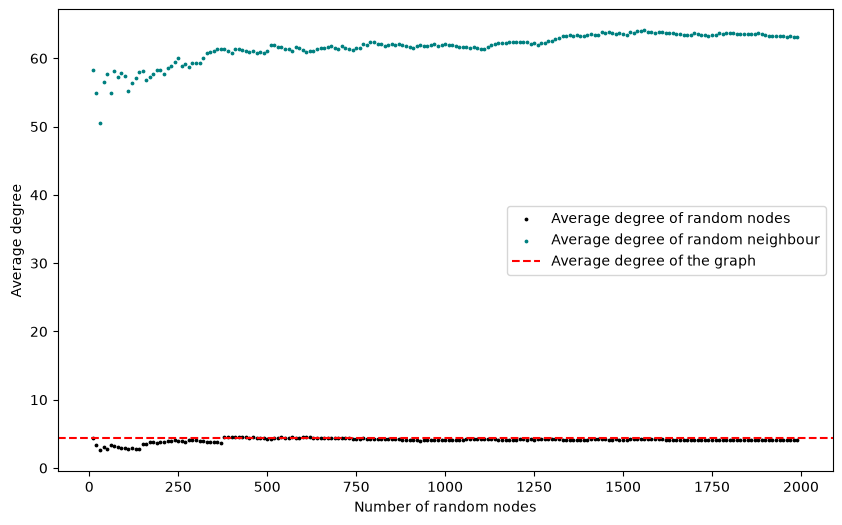

Average degree of the graph: 43.69
Average degree of random neighbour: 61.68


In [48]:
Rs = np.arange(10, 2000, 10)

avg_degrees_air, avg_degrees_neighbour_air = compute_avg_deg_of_random_nodes_and_neighbors(G_air, Rs)

plt.figure(figsize=(10, 6))
plt.scatter(Rs, avg_degrees_air, color="black", s=3, label="Average degree of random nodes")
plt.scatter(Rs, avg_degrees_neighbour_air, color="teal", s=3, label="Average degree of random neighbour")
plt.axhline(y=avg_degree_air, color="red", linestyle="--", label="Average degree of the graph")

plt.xlabel("Number of random nodes")
plt.ylabel("Average degree")
plt.legend()
plt.show()

print(f"Average degree of the graph: {avg_degree:.2f}")
print(f"Average degree of random neighbour: {np.mean(avg_degrees_neighbour_air):.2f}")

# Quiz 3

In [49]:
N = 100     # Estimated number of surfers in Bondi on a Thursday Morning

In [65]:
S = (1000 * 25 * 50) / (5e-5)**3     # Number of sand grains in Bondi

# Need n such that M = 2 ^ (n(n-1)/2) > S
a = 2 * np.log2(S)
n = (1 + np.sqrt(1 + 4*a)) / 2

print("Smallest sumber of surfers N required to have larger number of possible friendship networks than grains of sand in Bondi:")
print(round(n,0))

Smallest sumber of surfers N required to have larger number of possible friendship networks than grains of sand in Bondi:
12.0
